Langkah 1: Memuat data...
Langkah 2: Membuat fitur baru yang cerdas (Feature Engineering)...
Fitur baru berhasil dibuat:
                          seller_id week_start  total_sales  seller_avg_sales  \
0  0015a82c2db000af6aaaf3ae2ecb0532 2017-10-09       916.02            916.02   
1  0015a82c2db000af6aaaf3ae2ecb0532 2017-10-16       916.02            916.02   
2  001cca7ae9ae17fb1caed9dfb1094831 2017-02-13       573.85            121.05   
3  001cca7ae9ae17fb1caed9dfb1094831 2017-02-20       116.30            347.45   
4  001cca7ae9ae17fb1caed9dfb1094831 2017-02-27       841.07            270.40   

   month  
0     10  
1     10  
2      2  
3      2  
4      2  

Langkah 3: Visualisasi distribusi data penjualan asli...


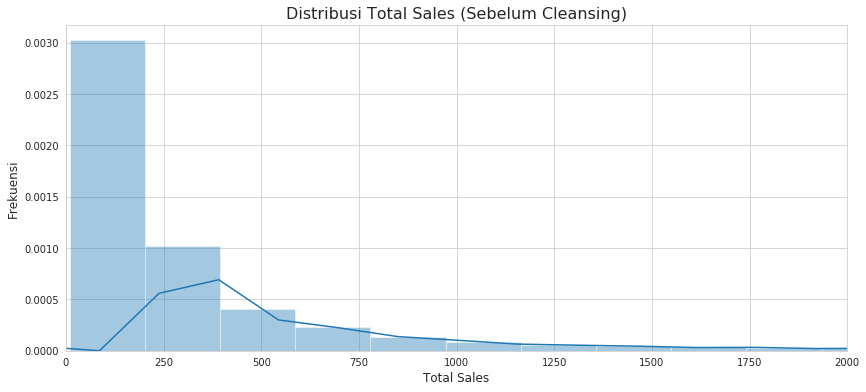

Insight: Distribusi sangat miring, sulit untuk dipelajari model.

Langkah 4: Menerapkan Log Transform dan visualisasi hasilnya...


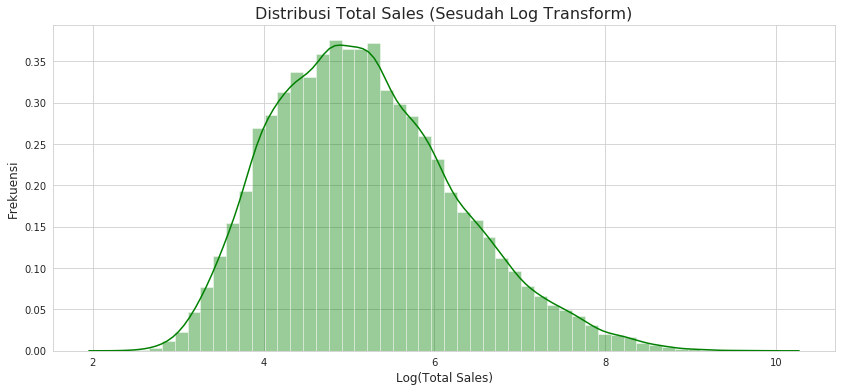

Insight: Distribusi sekarang jauh lebih simetris dan ideal.

Langkah 5: Melatih model Gradient Boosting...
Model berhasil dilatih.

Langkah 6: Mengevaluasi performa model...

--- Hasil Evaluasi Final (di Skala Asli) ---
Root Mean Squared Error (RMSE): 101.36
R-squared (R2): 0.9749

--- Metrik Persentase ---
MAPE (dengan floor $1.0): 1.00%
sMAPE (Symmetric MAPE): 1.00%
WAPE (Weighted MAPE): 2.37%  <-- Bisa untuk Insight Bisnis

--- Hasil Evaluasi Final (di Skala Log, blm ditransform lagi) ---
Root Mean Squared Error (RMSE) di Skala Log: 0.0167
R-squared (R2) di Skala Log: 0.9998

Langkah 7: Visualisasi performa akhir model...


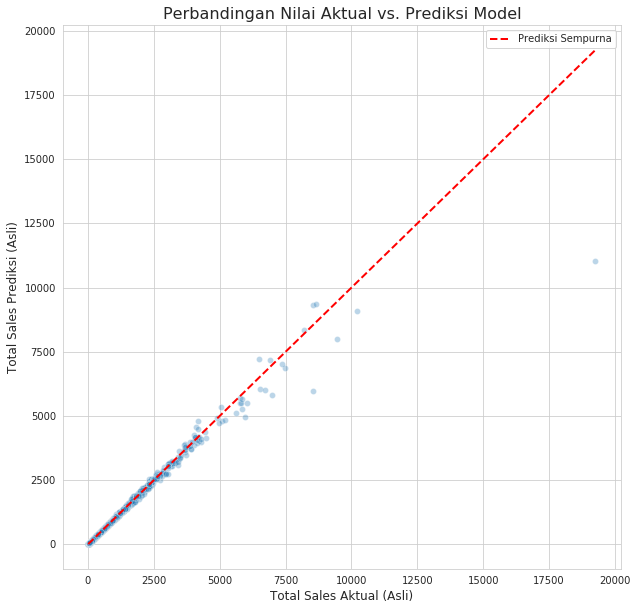

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# FUNGSI METRIK KUSTOM

def mape_floor(y_true, y_pred, floor=1.0):
    """
    Menghitung MAPE dengan ambang batas bawah (floor).
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true >= floor
    if not np.any(mask):
        return np.inf
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    """
    NGITUNGGGGG sMAPE (Symmetric Mean Absolute Percentage Error).
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if not np.any(mask):
        return 0.0
    return np.mean(numerator[mask] / denominator[mask]) * 100

def wape(y_true, y_pred):
    """
    Ngitungg WAPE (Weighted Absolute Percentage Error).
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true))
    if denominator == 0:
        return np.inf
    return (numerator / denominator) * 100

# style visualize
sns.set_style("whitegrid")
plt.rc('figure', figsize=(12, 6))

try:
    # --- 1. Ngimpor Data ---
    print("\n masokin data")
    df = pd.read_csv("sales_data.csv")
    df['week_start'] = pd.to_datetime(df['week_start'])
    df = df.dropna(subset=['total_sales', 'seller_id', 'product_category_name'])
    df = df.sort_values(by=['seller_id', 'week_start']).reset_index(drop=True)

    # --- 2. Feature Engineering ---
    print("\n fitur baru dibuat")
    df['seller_avg_sales'] = df.groupby('seller_id')['total_sales'].transform(lambda x: x.shift(1).expanding().mean()).fillna(0)
    df['seller_order_count'] = df.groupby('seller_id')['total_orders'].transform(lambda x: x.shift(1).expanding().sum()).fillna(0)
    df['seller_weeks_active'] = df.groupby('seller_id').cumcount()
    df['month'] = df['week_start'].dt.month
    df['week_of_year'] = df['week_start'].dt.weekofyear.astype(int)
    df = df[df['seller_weeks_active'] > 0].reset_index(drop=True)
    
    print("Fitur baru berhasil dibuat:")
    print(df[['seller_id', 'week_start', 'total_sales', 'seller_avg_sales', 'month']].head())

    # --- 3. Visualisasi DATA SEBELUM DIBERSIHKAN ---
    print("\n visualin dist")
    plt.figure(figsize=(14, 6))
    sns.distplot(df['total_sales'], bins=100)
    plt.title('Distribusi Total Sales (Sebelum Cleansing)', fontsize=16)
    plt.xlabel('Total Sales', fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    plt.xlim(0, 2000)
    plt.savefig('1_before_cleansing_distribution.png')
    plt.show()
    print("Insight: Distribusi sangat miring, sulit untuk dipelajari model.")

    # --- 4. Proses pembersihan dengan Log Transform & Visualisasi SESUDAHNYA ---
    print("\n log transform n visual (biar tau)")
    df['total_sales_log'] = np.log1p(df['total_sales'])
    
    plt.figure(figsize=(14, 6))
    sns.distplot(df['total_sales_log'], bins=50, color='green')
    plt.title('Distribusi Total Sales (Sesudah Log Transform)', fontsize=16)
    plt.xlabel('Log(Total Sales)', fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    plt.savefig('2_after_cleansing_distribution.png')
    plt.show()
    print("Insight: Distribusi sekarang jauh lebih simetris dan ideal.")

    # 5. Persiapan & Pelatihan Model 
    print("\n train rgbt progress")
    X = df.drop(['total_sales', 'total_sales_log', 'week_start', 'seller_city'], axis=1)
    y = df['total_sales_log']
    categorical_features = ['product_category_name', 'seller_id', 'seller_state']
    numerical_features = X.select_dtypes(include=np.number).columns.tolist()
    preprocessor = ColumnTransformer(transformers=[('num', 'passthrough', numerical_features), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)], remainder='drop')
    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(random_state=42, n_estimators=200, max_depth=5))])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model_pipeline.fit(X_train, y_train)
    print("Model berhasil dilatih.")

    # 6. Evaluasi dengan Metrik Lengkap
    print("\n evaluasi performa model...")
    
    log_predictions = model_pipeline.predict(X_test)
    y_test_original = np.expm1(y_test)
    predictions_original = np.expm1(log_predictions)
    
    # a. Evaluasi di Skala Asli
    print("\n Hasil Evaluasi Final (di Skala Asli)")
    rmse = np.sqrt(mean_squared_error(y_test_original, predictions_original))
    r2 = r2_score(y_test_original, predictions_original)
    mape_val = mape_floor(y_test_original, predictions_original, floor=1.0)
    smape_val = smape(y_test_original, predictions_original)
    wape_val = wape(y_test_original, predictions_original)

    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2): {r2:.4f}")
    print("\n Metrik Persentase")
    print(f"MAPE (dengan floor $1.0): {mape_val:.2f}%")
    print(f"sMAPE (Symmetric MAPE): {smape_val:.2f}%")
    print(f"WAPE (Weighted MAPE): {wape_val:.2f}%  <-- Bisa untuk Insight Bisnis")

    # b. Evaluasi di Skala Log (untuk perbandingan akademis)
    print("\n Hasil Evaluasi Final (di Skala Log, blm ditransform lagi)")
    rmse_log = np.sqrt(mean_squared_error(y_test, log_predictions))
    r2_log = r2_score(y_test, log_predictions)
    print(f"Root Mean Squared Error (RMSE) di Skala Log: {rmse_log:.4f}")
    print(f"R-squared (R2) di Skala Log: {r2_log:.4f}")
    
    # 7. Visualisasi Performa Akhir
    print("\n visual trakher...")
    plt.figure(figsize=(10, 10))
    sns.scatterplot(x=y_test_original, y=predictions_original, alpha=0.3)
    plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], '--', color='red', linewidth=2, label='Prediksi Sempurna')
    plt.title('Perbandingan Nilai Aktual vs. Prediksi Model', fontsize=16)
    plt.xlabel('Total Sales Aktual (Asli)', fontsize=12)
    plt.ylabel('Total Sales Prediksi (Asli)', fontsize=12)
    plt.legend()
    plt.savefig('3_model_performance_scatter.png')
    plt.show()

except FileNotFoundError:
    print("ERROR: file kg ada, directory yg sama aj")
except Exception as e:
    print(f"error: {e}")